In [2]:
%cd /home/govind/gov_semproject/GridCellsCopy

/home/govind/gov_semproject/GridCellsCopy


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import g_utils
import analysis_utils as a_utils
from interneuron import Interneuron
import sim_utils as s_utils
from neuron import h

h.load_file("stdrun.hoc")
h.cvode_active(1)

1.0

Current : 0.0nA
[]
Current : 0.001nA
[1.35228812e+01 2.81221268e+02 5.42704603e+02 8.04147482e+02
 1.06559606e+03 1.32704862e+03 1.58850695e+03 1.84994901e+03
 2.11134881e+03 2.37281774e+03 2.63423404e+03 2.89569386e+03
 3.15712217e+03 3.41858514e+03 3.68003405e+03 3.94150271e+03
 4.20294476e+03 4.46434550e+03 4.72579424e+03 4.98721113e+03
 5.24867149e+03 5.51010089e+03 5.77155293e+03 6.03300342e+03
 6.29446804e+03 6.55593312e+03 6.81733650e+03 7.07880475e+03
 7.34022480e+03 7.60168387e+03 7.86310866e+03 8.12456711e+03
 8.38600578e+03 8.64747412e+03 8.90893617e+03 9.17033290e+03
 9.43179455e+03 9.69320897e+03 9.95469053e+03 1.02161196e+04
 1.04775774e+04 1.07390145e+04 1.10004834e+04 1.12619448e+04
 1.15233367e+04 1.17847806e+04 1.20462079e+04 1.23076623e+04
 1.25690949e+04 1.28305449e+04 1.30919971e+04 1.33534693e+04
 1.36149315e+04 1.38763346e+04 1.41377964e+04 1.43992084e+04
 1.46606671e+04 1.49221035e+04 1.51835751e+04 1.54450114e+04
 1.57064816e+04 1.59679454e+04 1.62293281e+04 1.

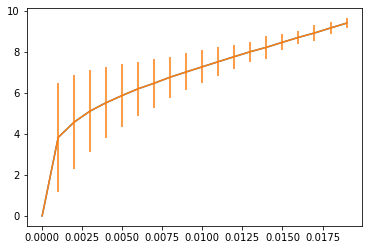

In [12]:
test_interneuron = Interneuron(0)

def f_i_const_curr(curr_amp,time_ms,sigma=50):
    
    ic = h.IClamp(test_interneuron.soma(0.5))
    #ic.delay=0
    ic.dur = 1e9
    #ic_amp = curr_amp
    T,num_steps = time_ms/1000, time_ms
    time_arr = np.linspace(0,T,num_steps)
    curr_arr = np.full(time_arr.shape,curr_amp)

    curr_vec = h.Vector(curr_arr)
    
    curr_vec.play(ic, ic._ref_amp, True)
    rec_i = h.Vector().record(ic._ref_amp)
    rec_v = h.Vector().record(test_interneuron.soma(0.5)._ref_v)
    rec_t = h.Vector().record(h._ref_t)
    spike_times = h.Vector()

    nc = h.NetCon(test_interneuron.soma(0.5)._ref_v, None, sec=test_interneuron.soma)
    nc.threshold=0
    nc.record(spike_times)

    h.finitialize(-70)
    h.continuerun(time_ms)

    np_spike_array = np.array(spike_times.to_python())
    print(np_spike_array)
    firing_rate = a_utils.instant_rate(spike_train=spike_times,sim_dur=time_ms,stdev=sigma)*1000 #converting to Hz
    
    del nc,ic,spike_times

    return np.mean(firing_rate), np.std(firing_rate)

    

curr_amp_list = [i*1e-3 for i in range(0,20)]

freq_mean_list=[]
freq_std_list =[]
for amp in curr_amp_list:
    print(f"Current : {amp}nA")
    mean,std = f_i_const_curr(curr_amp=amp,time_ms=20000,sigma=50)
    freq_mean_list.append(mean)
    freq_std_list.append(std)

plt.plot(curr_amp_list,freq_mean_list)
plt.errorbar(curr_amp_list,freq_mean_list,yerr=freq_std_list)
plt.show()
     


